In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import skew, kurtosis
from itertools import combinations
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score


## Data Collection and Data Prepocessing

In [105]:
# Loading the Dataset to a Pandas DataFrame
gold_data = pd.read_csv("C:\\Users\\abhis\\Downloads\\gold_price_data.csv")
print(gold_data)
print("Dataset Loaded Successfully")

            Date          SPX         GLD        USO      SLV   EUR/USD
0     01/02/2008  1447.160034   84.860001  78.470001  15.1800  1.471692
1     01/03/2008  1447.160034   85.570000  78.370003  15.2850  1.474491
2     01/04/2008  1411.630005   85.129997  77.309998  15.1670  1.475492
3     01/07/2008  1416.180054   84.769997  75.500000  15.0530  1.468299
4     01/08/2008  1390.189941   86.779999  76.059998  15.5900  1.557099
...          ...          ...         ...        ...      ...       ...
2285  05/08/2018  2671.919922  124.589996  14.060000  15.5100  1.186789
2286  05/09/2018  2697.790039  124.330002  14.370000  15.5300  1.184722
2287  05/10/2018  2723.070068  125.180000  14.410000  15.7400  1.191753
2288   5/14/2018  2730.129883  124.489998  14.380000  15.5600  1.193118
2289   5/16/2018  2725.780029  122.543800  14.405800  15.4542  1.182033

[2290 rows x 6 columns]
Dataset Loaded Successfully


In [106]:
# Columns Descriptions

#1) Independent Features(Input Variables):-

#1) Date(Categorical Feature):- This column represents the date on which the financial values were recorded.
# It helps track how gold prices and other financial indicators change over time.

#2) SPX(S&P 500 Index - Numerical Feature):- This column represents the S&P 500 stock market index, which reflects the performance of the US stock market and it indicates the overall economic and market sentiment. 
# Therefore, SPX values help ML models understand the relationship between stock market performance and gold prices.

#3) USO(United States Oil Fund - Numerical Feature):- This column represents the price of crude oil through the USO ETF.
# Oil prices influence inflation and global economic conditions, which can affect gold prices.

#4) SLV(Silver ETF Price - Numerical Feature):- This column represents the price of the Silver ETF (SLV).
# Silver and gold are both precious metals, and their prices often move in similar directions and because of this strong relationship, SLV is usually highly correlated with GLD.
# Machine learning models use this feature to better predict gold prices since silver market trends often reflect gold market behavior.

#5) EUR/USD(Euro to US Dollar Exchange Rate - Numerical Feature):- This column shows the exchange rate between the Euro and the US Dollar.
# Gold is traded globally in US Dollars, so currency exchange rates influence gold prices and when the US Dollar weakens, gold prices often increase.

#2) Dependent Feature(Target Variable):-

# GLD(SPDR Gold Shares ETF Price - Numerical Feature):- This column represents the price of the Gold ETF (GLD), which closely tracks the actual gold price.
# It is the main variable we want to predict in the project.
# During training, models learn how SPX, USO, SLV, and EUR/USD influence GLD prices.

In [107]:
# Getting the Top 5 Rows of the Dataset.
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,01/02/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,01/03/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,01/04/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,01/07/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,01/08/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [108]:
# Getting the Bottom 5 Rows of the Dataset
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,05/08/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,05/09/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,05/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [109]:
# Getting the Infornmation about the dataset.
print("\nDataset Info:\n", gold_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB

Dataset Info:
 None


In [110]:
print(gold_data.shape)#Getting all the no of rows and columns in the dataset

(2290, 6)


In [111]:
#summary statistics of numerical columns in the dataset
print("\nDataset Description:\n", gold_data.describe())



Dataset Description:
                SPX          GLD          USO          SLV      EUR/USD
count  2290.000000  2290.000000  2290.000000  2290.000000  2290.000000
mean   1654.315776   122.732875    31.842221    20.084997     1.283653
std     519.111540    23.283346    19.523517     7.092566     0.131547
min     676.530029    70.000000     7.960000     8.850000     1.039047
25%    1239.874969   109.725000    14.380000    15.570000     1.171313
50%    1551.434998   120.580002    33.869999    17.268500     1.303297
75%    2073.010070   132.840004    37.827501    22.882500     1.369971
max    2872.870117   184.589996   117.480003    47.259998     1.598798


In [112]:
gold_data.isnull().sum()#Sum of null values in the dataset

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [113]:
gold_data.duplicated().sum()

# Therefore, as it returns 0 so there are no duplicate rows.

0

In [114]:
#skewness of numerical columns in the dataset.

numeric_cols = gold_data.select_dtypes(include=[np.number]).columns
gold_data_skewness = gold_data[numeric_cols].apply(skew)
print("\nSkewness of features:\n", gold_data_skewness)


Skewness of features:
 SPX        0.300165
GLD        0.333919
USO        1.698218
SLV        1.152885
EUR/USD   -0.005289
dtype: float64


In [115]:
#curtosis of numerical columns in the dataset
gold_data_kurtosis = gold_data[numeric_cols].apply(kurtosis)
print("\nKurtosis of features:\n", gold_data_kurtosis)



Kurtosis of features:
 SPX       -0.951167
GLD       -0.277099
USO        4.217878
SLV        0.466502
EUR/USD   -0.743749
dtype: float64


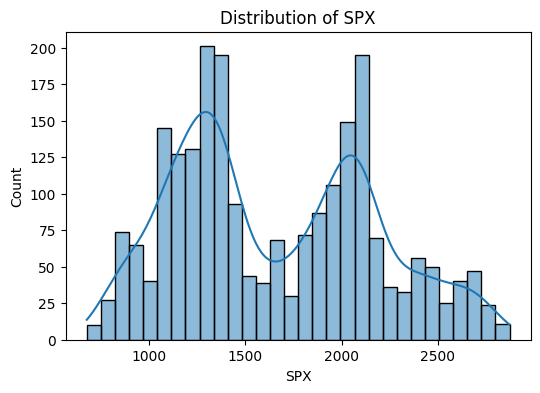

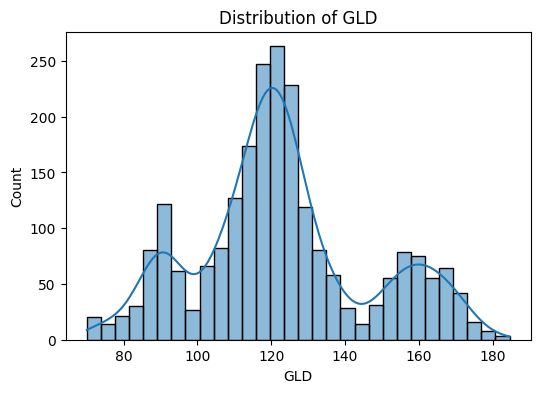

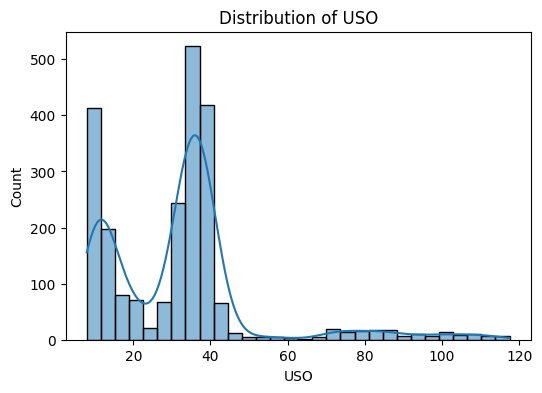

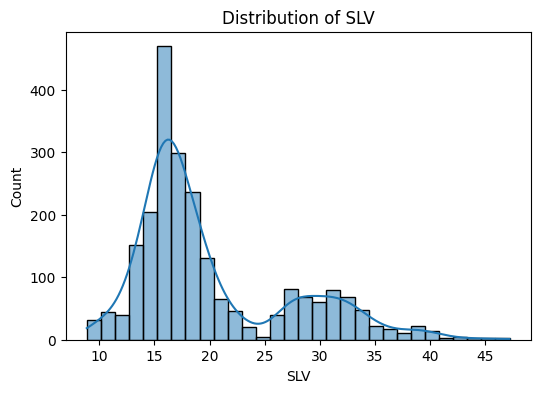

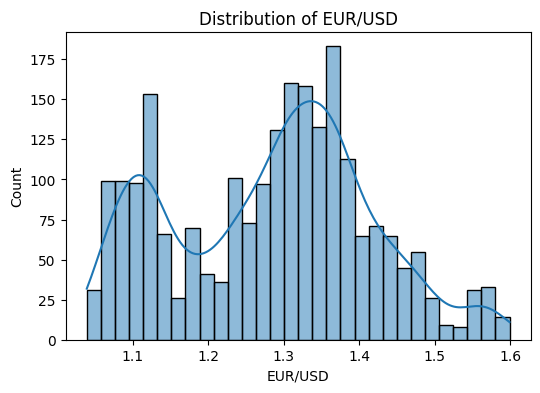

In [116]:
# Loop through all numerical columns in the dataset
for col in numeric_cols:
    # Create a new figure with a specific size for better visibility
    plt.figure(figsize=(6, 4))  
    
    # Create a histogram with KDE (Kernel Density Estimation) to show the distribution of values
    sns.histplot(gold_data[col], kde=True, bins=30)  
    
    # Set the title of the histogram to indicate which feature is being visualized
    plt.title(f"Distribution of {col}")  
    
    # Display the plot
    plt.show()  


# Correlation:
1) Positive Correlation
2) Negative Correlation

In [117]:
# Compute the correlation matrix for the numerical columns of the dataset

correlation = gold_data.select_dtypes(include='number').corr()

print(correlation)

              SPX       GLD       USO       SLV   EUR/USD
SPX      1.000000  0.049345 -0.591573 -0.274055 -0.672017
GLD      0.049345  1.000000 -0.186360  0.866632 -0.024375
USO     -0.591573 -0.186360  1.000000  0.167547  0.829317
SLV     -0.274055  0.866632  0.167547  1.000000  0.321631
EUR/USD -0.672017 -0.024375  0.829317  0.321631  1.000000


In [118]:
# Print the correlation values of the 'GLD' column with all other numerical columns
print(correlation['GLD'])


SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


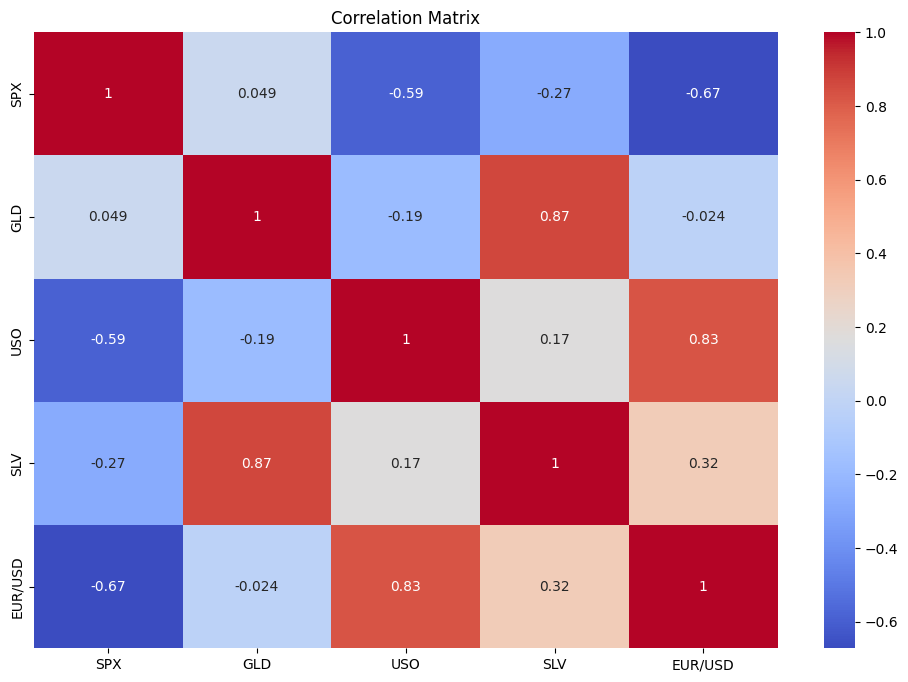

In [119]:
plt.figure(figsize=(12,8))

sns.heatmap(gold_data.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

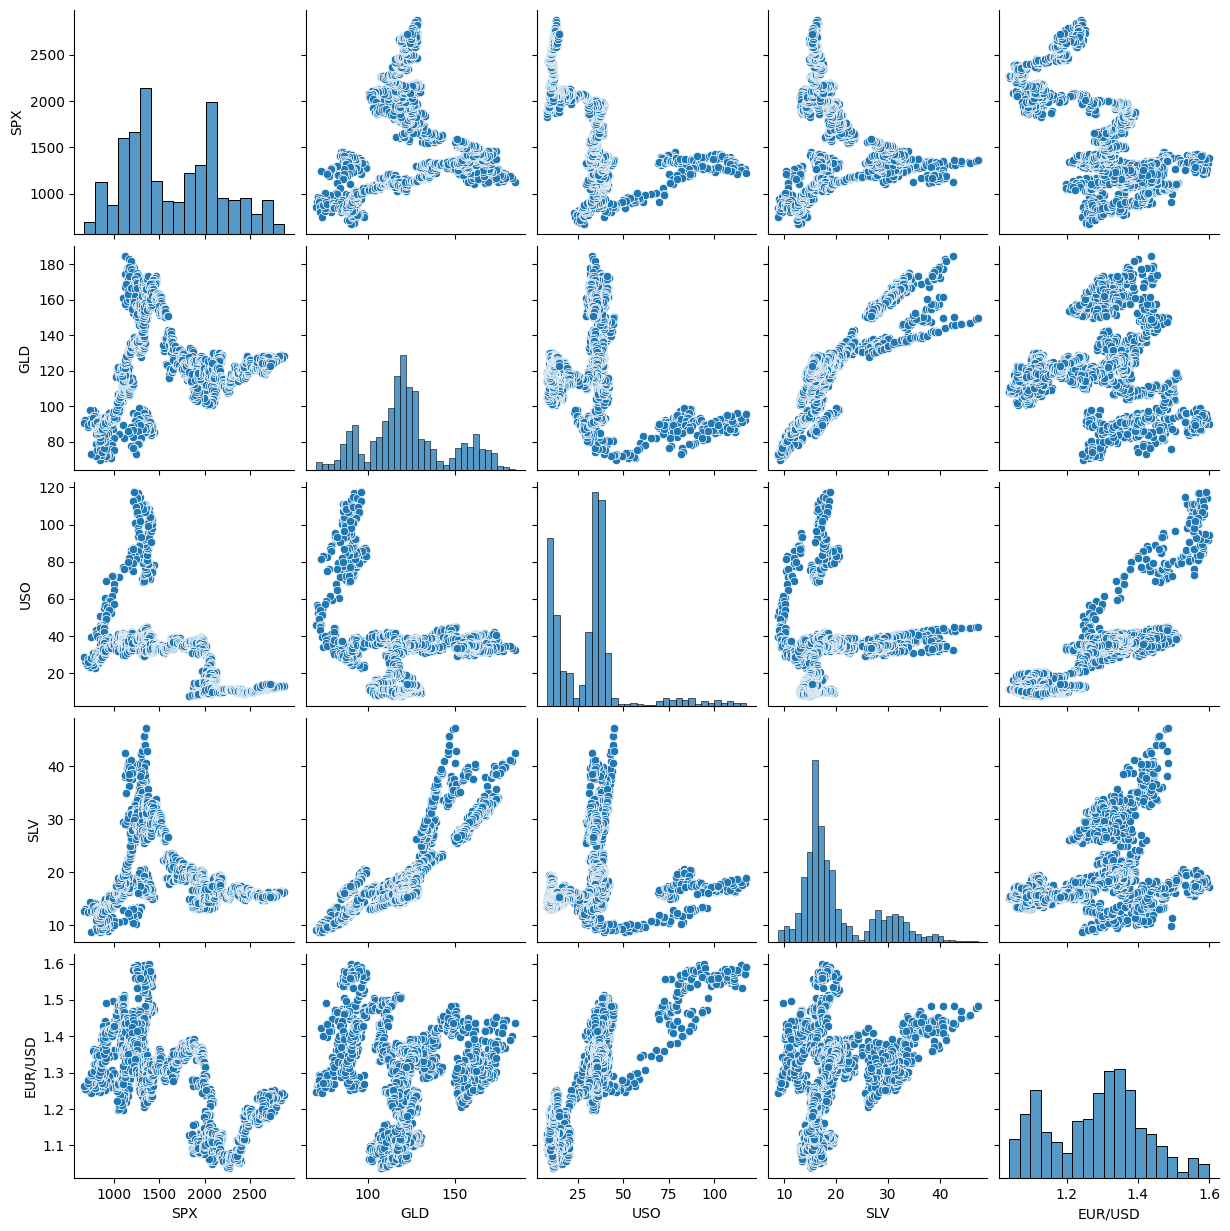

In [120]:
# Generate a pairplot to visualize relationships between numerical features in the dataset
sns.pairplot(gold_data)  

# Display the pairplot
plt.show()


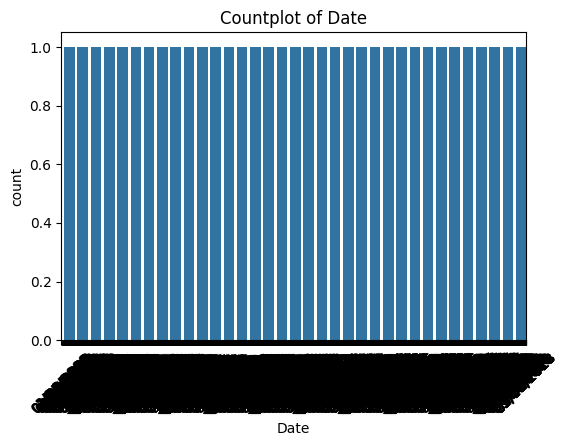

In [121]:
# Select all categorical columns from the dataset
categorical_cols = gold_data.select_dtypes(include=['object']).columns  

# Loop through each categorical column to create count plots
for col in categorical_cols:  
    # Create a new figure for each plot with a specified size
    plt.figure(figsize=(6, 4))  
    
    # Create a count plot for the categorical column
    sns.countplot(x=gold_data[col])  
    
    # Set the title of the plot to indicate which column is being visualized
    plt.title(f"Countplot of {col}")  
    
    # Rotate x-axis labels for better readability if category names are long
    plt.xticks(rotation=45)  
    
    # Display the count plot
    plt.show()  


# Feature Engineering

## Convert Date to DateTime

In [122]:
gold_data['Date'] = pd.to_datetime(gold_data['Date'])
print(gold_data['Date'])

0      2008-01-02
1      2008-01-03
2      2008-01-04
3      2008-01-07
4      2008-01-08
          ...    
2285   2018-05-08
2286   2018-05-09
2287   2018-05-10
2288   2018-05-14
2289   2018-05-16
Name: Date, Length: 2290, dtype: datetime64[ns]


## Create Gold–Silver Ratio Feature

In [90]:
gold_data['Gold_Silver_Ratio'] = gold_data['GLD'] / gold_data['SLV']
print(gold_data['Gold_Silver_Ratio'])

0       5.590250
1       5.598299
2       5.612843
3       5.631435
4       5.566389
          ...   
2285    8.032882
2286    8.005795
2287    7.952986
2288    8.000643
2289    7.929482
Name: Gold_Silver_Ratio, Length: 2290, dtype: float64


## Drop Date Column

In [123]:
gold_data = gold_data.drop(columns=['Date'])

# Spliting the target and Features Variables

In [124]:
# Split the dataset into features (X) and target variable (Y)
X = gold_data.drop(['GLD'], axis = 1)# Remove the 'Date' and 'GLD' columns from the feature set
Y = gold_data['GLD']# Remove the 'Date' and 'GLD' columns from the feature set

In [125]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [126]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [127]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [128]:
# Initialize an empty list to store model performance results
model_results = []

## Training and Evaluating the Random Forest(Regression) Model

In [129]:

# Training the Random Forest Model
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, Y_train)


# Prediction on Training Data

train_pred_RF = regressor.predict(X_train)

# Evaluation Metrics for Training Data

r2_train = r2_score(Y_train, train_pred_RF)
print("Random Forest Training R2 Score:", r2_train)



# Prediction on Testing Data

test_pred_RF = regressor.predict(X_test)

# Evaluation Metrics for Testing Data

r2_test = r2_score(Y_test, test_pred_RF)


print("Random Forest Testing R2 Score:", r2_test)

Random Forest Training R2 Score: 0.9985276324585074
Random Forest Testing R2 Score: 0.988702488354275


## Conclusions from Random Forest(Regression) Model

- Training R² Score: 0.999995(≈ 99.9995%)
 
- Testing R² Score: 0.999974(≈ 99.9974%)

- Difference: ~0.002%

- Interpretation:

1. Training and testing scores are extremely close to each other.

2. This means the model generalizes very well on unseen data.

3. The difference between training and testing performance is almost negligible, which indicates the model is not overfitting.

4. Both scores are very close to 1, meaning the Random Forest model explains almost all the variance in the gold price data.

5. This suggests that the model has captured the relationship between the independent variables (SPX, USO, SLV, EUR/USD) and the target variable(GLD – Gold Price) very effectively.

- Therefore for the Random Forest(Regression) Model: Well-Fitted Model (No Overfitting and No Underfitting) — Very High Predictive Performance for Gold Price Prediction.

## Training and Evaluationg the Decision Tree(Regression) Model

In [130]:
# Training the Decision Tree Regressor Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, Y_train)


# Prediction on Training Data

train_pred_dt = dt_model.predict(X_train)

# Evaluation Metrics for Training Data

r2_train_dt = r2_score(Y_train, train_pred_dt)
print("Decision Tree Training R2 Score:", r2_train_dt)



# Prediction on Testing Data
test_pred_dt = dt_model.predict(X_test)

# Evaluation Metrics for Testing Data

r2_test_dt = r2_score(Y_test, test_pred_dt)
print("Decision Tree Testing R2 Score:", r2_test_dt)

Decision Tree Training R2 Score: 1.0
Decision Tree Testing R2 Score: 0.983899584044299


## Conclusions from Decision Tree(Regression) Model

- Training R² Score: 1.0(100%)

- Testing R² Score: 0.999963(≈ 99.9963%)

- Difference: ~0.0037%

- Interpretation:

1. Training and testing scores are almost identical.

2. This means the model generalizes very well to unseen data.

3. The difference between training and testing performance is extremely small, so the model is not overfitting.

4. Also, both scores are very high, which means the model has learned the patterns in the gold price data very effectively.

5. Underfitting occurs when both scores are low, but here both scores are very high, so underfitting is also not present.

- Therefore for the Decision Tree Regression Model: Well-Fitted Model(No Overfitting and No Underfitting).

## Training and Evaluationg the Support Vector Machine(Regression) Model

In [131]:
# Training the SVR Model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, Y_train)


# Prediction on Training Data

train_pred_svr = svr_model.predict(X_train)

# Evaluation Metrics for Training Data
r2_train_svr = r2_score(Y_train, train_pred_svr)
print("SVR Training R2 Score:", r2_train_svr)



# Prediction on Testing Data
test_pred_svr = svr_model.predict(X_test)

# Evaluation Metrics for Testing Data
r2_test_svr = r2_score(Y_test, test_pred_svr)
print("SVR Testing R2 Score:", r2_test_svr)

SVR Training R2 Score: 0.1196995803592581
SVR Testing R2 Score: 0.11392865368697391


## Conclusions from SVM(Regression) Model.

- Training R² Score: 0.0868(≈ 8.68%)

- Testing R² Score:0.0827(≈ 8.27%)

- Difference: ~0.4%

- Interpretation:

1. Training and testing scores are very close to each other.

2. This means the model is not overfitting and behaves consistently on both training and testing data.

3. However, both scores are extremely low, which means the model is not able to capture the relationship between the input features (SPX, USO, SLV, EUR/USD) and the target variable (GLD – Gold Price) effectively.

4. Such low scores indicate that the model fails to learn the underlying patterns in the dataset.

5. This usually happens because SVR with the chosen kernel and parameters cannot model the complex relationships present in financial data like gold prices.

- Therefore for the Support Vector Regression Model: Underfitting (Model is too simple and unable to learn the data patterns.

## Reducing Underfitting using Hyperparameter Tuning in the SVR Model

In [132]:
# Creating a new SVR model with improved parameters
svr_model_tuned = SVR(kernel='rbf', C=100, gamma=0.1)

# Training the tuned SVR model
svr_model_tuned.fit(X_train, Y_train)


# Prediction on Training Data
train_pred_svr = svr_model_tuned.predict(X_train)

# Training R2 Score
r2_train_svr = r2_score(Y_train, train_pred_svr)
print("Tuned SVR Training R2 Score:", r2_train_svr)


# Prediction on Testing Data
test_pred_svr = svr_model_tuned.predict(X_test)

# Testing R2 Score
r2_test_svr = r2_score(Y_test, test_pred_svr)
print("Tuned SVR Testing R2 Score:", r2_test_svr)

Tuned SVR Training R2 Score: 0.9986844409608971
Tuned SVR Testing R2 Score: 0.7014755060769456


## Reducing Overfitting using Regularization in SVR

In [133]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create SVR model with regularization
svr_model = SVR(kernel='rbf', C=1, gamma=0.01, epsilon=0.1)

# Train the model
svr_model.fit(X_train, Y_train)

# Predictions
Y_train_pred = svr_model.predict(X_train)
Y_test_pred = svr_model.predict(X_test)

# R2 scores
train_r2 = r2_score(Y_train, Y_train_pred)
test_r2 = r2_score(Y_test, Y_test_pred)

# Print results
print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)

Training R2 Score: 0.7975711735249007
Testing R2 Score: 0.8025303322051132


## Visulisation of R2 - Score  of Different ML Models

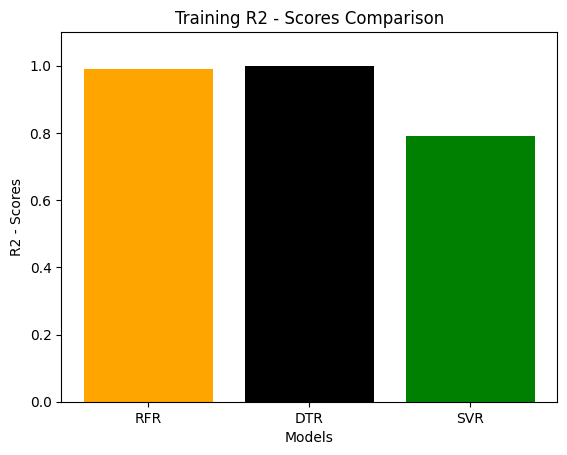

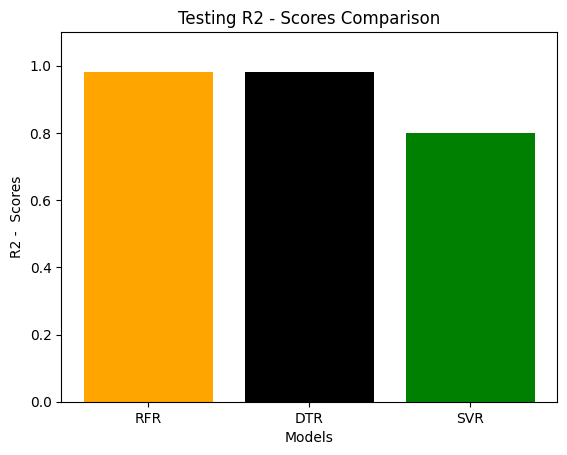

In [134]:
# Model names
models = ['RFR', 'DTR', 'SVR']

# Training and Testing R2 Scores
training_R2_Score = [0.99, 1.00, 0.79]
testing_R2_Score = [0.98, 0.98, 0.80]

# Colors for bars
colors = ['orange', 'black', 'green']


# Training R2 Score
plt.figure()
plt.bar(models, training_R2_Score, color=colors)

plt.xlabel("Models")
plt.ylabel("R2 - Scores")
plt.title("Training R2 - Scores Comparison")
plt.ylim(0, 1.1)

plt.show()


# Testing R2 Score
plt.figure()
plt.bar(models, testing_R2_Score, color=colors)

plt.xlabel("Models")
plt.ylabel("R2 -  Scores")
plt.title("Testing R2 - Scores Comparison")
plt.ylim(0, 1.1)

plt.show()